# Step 4: Bayesian Change-Point and Time-Varying Reliability

Step 3 estimated one constant success probability. Step 4 asks whether the data support reliability changing over time. This notebook keeps the models small and interpretable because there are only 64 launches and 4 failures.

The main alternative is a Bayesian one-change-point model. A pre-specified C61/C62 recent-period model and a smooth logistic trend are secondary comparisons. No conclusion is forced: evidence for a change and uncertainty about its location are both reported.

## 1. Data and model definitions

The frozen Step 1 dataset is the only input.

**Model M0: constant reliability**

$$Y_i\mid p \sim Bernoulli(p),\qquad p\sim Beta(1,1).$$

**Model M1: one unknown change point**

$$Y_i\sim Bernoulli(p_1)\ (i\le k),\qquad Y_i\sim Bernoulli(p_2)\ (i>k).$$

The candidate change point has a uniform prior over `k = 10,...,54`, leaving at least 10 launches in each segment.

In [15]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.special import betaln, expit, logsumexp
from scipy.optimize import minimize
from scipy.stats import beta, norm

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == 'code' else HERE
INPUT_FILE = PROJECT_ROOT / 'data' / 'PSLV_verified_dataset_v1.0.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'step4'
FIGURES_DIR = PROJECT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True); FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(INPUT_FILE)
y = data['success'].astype(int).to_numpy()
n = len(y); successes = int(y.sum()); failures = n - successes
if (n, successes, failures) != (64, 60, 4): raise ValueError('Frozen dataset is not 64 launches, 60 successes, 4 failures')
print(f'n = {n}, successes = {successes}, failures = {failures}')

A = B = 1.0
MIN_SEGMENT = 10
CANDIDATE_K = np.arange(MIN_SEGMENT, n - MIN_SEGMENT + 1)
SIMULATIONS = 50000
rng = np.random.default_rng(20261001)

n = 64, successes = 60, failures = 4


## 2. Analytical marginal likelihood for a segment

For a segment with `s` successes and `f` failures, integrating out a Beta(1,1) probability gives:

$$m(s,f)=\frac{B(1+s,1+f)}{B(1,1)}.$$

For each possible `k`, the change-point evidence is the product of the evidence for the two segments. This lets us calculate `P(k | data)` without MCMC.

,k,posterior_probability
44,54,0.078495
43,53,0.062268
42,52,0.050716
41,51,0.042239
30,40,0.036852
40,50,0.035860
29,39,0.032781
39,49,0.030957
28,38,0.029394
38,48,0.027122


Posterior mode of k = 54; posterior mean of k = 37.42; 95% interval = [11, 54]


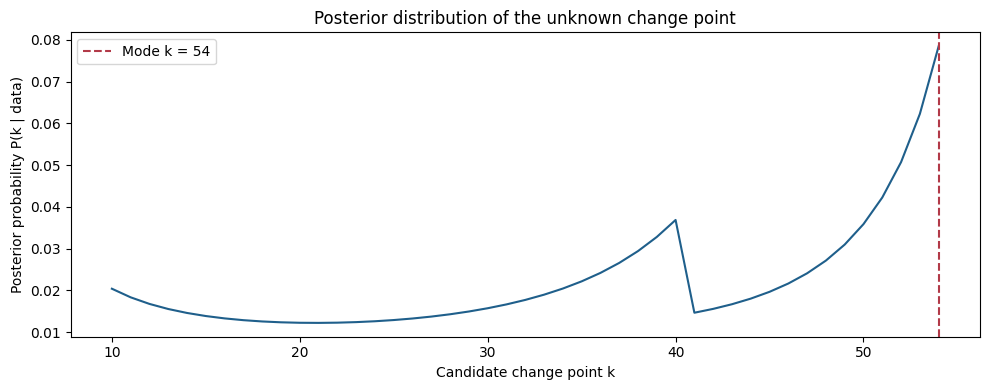

In [16]:
def segment_log_evidence(values, alpha=1.0, beta_parameter=1.0):
    s = int(np.sum(values)); f = len(values) - s
    return betaln(alpha + s, beta_parameter + f) - betaln(alpha, beta_parameter)

def fit_constant(values):
    log_evidence = segment_log_evidence(values)
    posterior = beta(1 + int(np.sum(values)), 1 + len(values) - int(np.sum(values)))
    return {'log_evidence': log_evidence, 'posterior': posterior}

def fit_change_point(values):
    candidates = np.arange(MIN_SEGMENT, len(values) - MIN_SEGMENT + 1)
    log_by_k = np.array([segment_log_evidence(values[:k]) + segment_log_evidence(values[k:]) for k in candidates])
    log_prior_k = -math.log(len(candidates))
    log_evidence = logsumexp(log_by_k + log_prior_k)
    posterior_k = np.exp(log_by_k + log_prior_k - log_evidence)
    return {'candidates': candidates, 'log_by_k': log_by_k, 'log_evidence': log_evidence, 'posterior_k': posterior_k}

constant = fit_constant(y)
change_point = fit_change_point(y)
k_table = pd.DataFrame({'k': change_point['candidates'], 'posterior_probability': change_point['posterior_k']})
k_mode = int(k_table.loc[k_table.posterior_probability.idxmax(), 'k'])
k_mean = float(np.sum(k_table.k * k_table.posterior_probability))
k_cdf = k_table.posterior_probability.cumsum()
k_lower = int(k_table.loc[k_cdf >= 0.025, 'k'].iloc[0])
k_upper = int(k_table.loc[k_cdf >= 0.975, 'k'].iloc[0])
display(k_table.sort_values('posterior_probability', ascending=False).head(10))
print(f'Posterior mode of k = {k_mode}; posterior mean of k = {k_mean:.2f}; 95% interval = [{k_lower}, {k_upper}]')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_table.k, k_table.posterior_probability, color='#1f5f8b')
ax.axvline(k_mode, color='#b23a48', linestyle='--', label=f'Mode k = {k_mode}')
ax.set_xlabel('Candidate change point k'); ax.set_ylabel('Posterior probability P(k | data)'); ax.set_title('Posterior distribution of the unknown change point'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_01_change_point_posterior.png', dpi=180); plt.show()

## 3. Before-versus-after reliability under M1

For each `k`, the segment posteriors are:

$$p_1|k,D\sim Beta(1+s_1,1+f_1),\qquad p_2|k,D\sim Beta(1+s_2,1+f_2).$$

We average over uncertain `k` by sampling `k` from `P(k|D)` and then sampling `p1` and `p2` from their conditional posteriors. The key practical quantities are `P(p1 > p2)`, `P(p1-p2 > 0.05)`, and `P(p1-p2 > 0.10)`.

,quantity,value
0,P(p_before > p_after),0.782440
1,P(p_before - p_after > 0.05),0.579520
2,P(p_before - p_after > 0.10),0.374600
3,Posterior mean p_before,0.929961
4,Posterior mean p_after,0.852055
5,Posterior mean degradation,0.077906


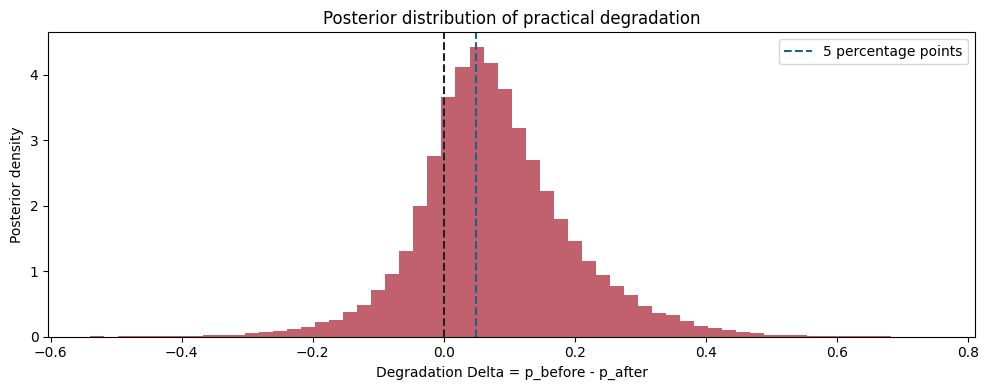

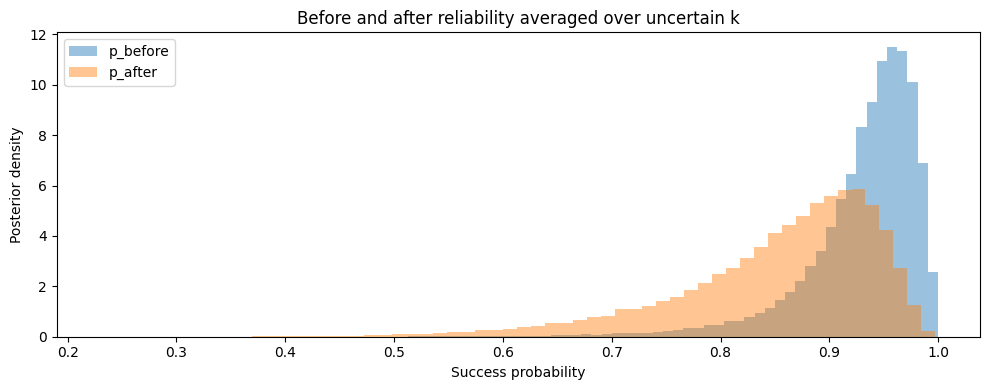

In [17]:
def sample_change_point_posterior(values, fit, draws=SIMULATIONS, seed=20261001):
    local_rng = np.random.default_rng(seed)
    selected_k = local_rng.choice(fit['candidates'], size=draws, p=fit['posterior_k'])
    p1 = np.empty(draws); p2 = np.empty(draws)
    for k in np.unique(selected_k):
        mask = selected_k == k
        first = values[:k]; second = values[k:]
        p1[mask] = local_rng.beta(1 + first.sum(), 1 + len(first) - first.sum(), mask.sum())
        p2[mask] = local_rng.beta(1 + second.sum(), 1 + len(second) - second.sum(), mask.sum())
    return selected_k, p1, p2

sampled_k, p_before, p_after = sample_change_point_posterior(y, change_point)
delta = p_before - p_after
regime_summary = pd.DataFrame([{
    'quantity': 'P(p_before > p_after)', 'value': np.mean(delta > 0)},
    {'quantity': 'P(p_before - p_after > 0.05)', 'value': np.mean(delta > 0.05)},
    {'quantity': 'P(p_before - p_after > 0.10)', 'value': np.mean(delta > 0.10)},
    {'quantity': 'Posterior mean p_before', 'value': p_before.mean()},
    {'quantity': 'Posterior mean p_after', 'value': p_after.mean()},
    {'quantity': 'Posterior mean degradation', 'value': delta.mean()},
])
display(regime_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delta, bins=60, density=True, color='#b23a48', alpha=0.8)
ax.axvline(0, color='#222222', linestyle='--'); ax.axvline(0.05, color='#1f5f8b', linestyle='--', label='5 percentage points')
ax.set_xlabel('Degradation Delta = p_before - p_after'); ax.set_ylabel('Posterior density'); ax.set_title('Posterior distribution of practical degradation'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_02_degradation_posterior.png', dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(p_before, bins=60, density=True, alpha=0.45, label='p_before')
ax.hist(p_after, bins=60, density=True, alpha=0.45, label='p_after')
ax.set_xlabel('Success probability'); ax.set_ylabel('Posterior density'); ax.set_title('Before and after reliability averaged over uncertain k'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_03_before_after_posteriors.png', dpi=180); plt.show()

## 4. Model comparison and the pre-specified recent model

The one-change-point model is compared with the constant model using marginal likelihoods. The Bayes factor is `exp(log evidence of alternative - log evidence of M0)`.

The recent model fixes `k=62` before fitting because C61 and C62 are the scientifically motivated recent period. This is a sensitivity model, not a data-discovered change point.

In [18]:
recent_k = 62
recent_log_evidence = segment_log_evidence(y[:recent_k]) + segment_log_evidence(y[recent_k:])
recent_old_posterior = beta(1 + y[:recent_k].sum(), 1 + recent_k - y[:recent_k].sum())
recent_new_posterior = beta(1 + y[recent_k:].sum(), 1 + len(y[recent_k:]) - y[recent_k:].sum())
recent_rng = np.random.default_rng(20261001)
recent_old_draws = recent_rng.beta(1 + y[:recent_k].sum(), 1 + recent_k - y[:recent_k].sum(), SIMULATIONS)
recent_new_draws = recent_rng.beta(1 + y[recent_k:].sum(), 1 + len(y[recent_k:]) - y[recent_k:].sum(), SIMULATIONS)
recent_delta = recent_old_draws - recent_new_draws
recent_summary = pd.DataFrame([{
    'quantity': 'P(p_old > p_recent)', 'value': np.mean(recent_delta > 0)},
    {'quantity': 'P(p_old - p_recent > 0.05)', 'value': np.mean(recent_delta > 0.05)},
    {'quantity': 'P(p_old - p_recent > 0.10)', 'value': np.mean(recent_delta > 0.10)},
    {'quantity': 'Posterior mean p_old', 'value': recent_old_posterior.mean()},
    {'quantity': 'Posterior mean p_recent', 'value': recent_new_posterior.mean()},
])
display(recent_summary)

# Simple Bayesian logistic trend using a small numerical grid.
time = (np.arange(n) - (n - 1) / 2) / (n / 2)
intercept_grid = np.linspace(-4, 4, 121); slope_grid = np.linspace(-4, 4, 121)
log_weights = np.empty((len(intercept_grid), len(slope_grid)))
for i, intercept in enumerate(intercept_grid):
    eta = intercept + slope_grid[:, None] * time[None, :]
    log_likelihood = (y[None, :] * (-np.logaddexp(0, -eta)) + (1-y[None, :]) * (-np.logaddexp(0, eta))).sum(axis=1)
    log_prior_slope = norm.logpdf(slope_grid, 0, 1)
    log_weights[i, :] = log_likelihood + norm.logpdf(intercept, 0, 2.5) + log_prior_slope
log_grid_weights = log_weights - logsumexp(log_weights)
trend_weights = np.exp(log_grid_weights)
trend_mean_slope = float(np.sum(trend_weights * slope_grid[None, :]))
trend_prob_decreasing = float(np.sum(trend_weights[:, slope_grid < 0]))
trend_log_evidence = float(logsumexp(log_weights) + math.log((intercept_grid[1]-intercept_grid[0]) * (slope_grid[1]-slope_grid[0])))
trend_summary = pd.DataFrame([{'quantity': 'Posterior mean slope', 'value': trend_mean_slope}, {'quantity': 'P(slope < 0)', 'value': trend_prob_decreasing}])
display(trend_summary)

model_comparison = pd.DataFrame([
    {'model': 'M0 constant', 'description': 'One p for all launches', 'log_marginal_likelihood': constant['log_evidence']},
    {'model': 'M1 unknown change point', 'description': 'Uniform k from 10 to 54', 'log_marginal_likelihood': change_point['log_evidence']},
    {'model': 'M2 recent k=62', 'description': 'Pre-specified C61/C62 recent regime', 'log_marginal_likelihood': recent_log_evidence},
    {'model': 'M3 smooth trend', 'description': 'Bayesian logistic trend grid', 'log_marginal_likelihood': trend_log_evidence},
])
model_comparison['Bayes_factor_vs_M0'] = np.exp(model_comparison.log_marginal_likelihood - constant['log_evidence'])
display(model_comparison)
model_comparison.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)

,quantity,value
0,P(p_old > p_recent),0.999840
1,P(p_old - p_recent > 0.05),0.998920
2,P(p_old - p_recent > 0.10),0.996380
3,Posterior mean p_old,0.953125
4,Posterior mean p_recent,0.250000


,quantity,value
0,Posterior mean slope,-0.535863
1,P(slope < 0),0.774733


,model,description,log_marginal_likelihood,Bayes_factor_vs_M0
0,M0 constant,One p for all launches,-17.536359,1.000000
1,M1 unknown change point,Uniform k from 10 to 54,-18.739963,0.300111
2,M2 recent k=62,Pre-specified C61/C62 recent regime,-12.786608,115.555556
3,M3 smooth trend,Bayesian logistic trend grid,-17.258776,1.319936


## 5. Posterior predictive checks under the change-point model

We simulate replicated 64-launch sequences from M1. The diagnostics examine total failures, failure clustering, the final two launches, and the last ten launches. These are model checks, not conventional hypothesis-test p-values.

,statistic,observed,predictive_mean,tail_probability
0,Total failures,4,5.55154,0.72508
1,Failure-to-failure transitions,1,0.74638,0.42914
2,"Runs, lower-tail",5,10.39248,0.17678
3,Failures in last 10,2,1.47366,0.40600
4,Final two launches fail,1,0.03118,0.03118
5,Longest failure run,2,1.54608,0.42914


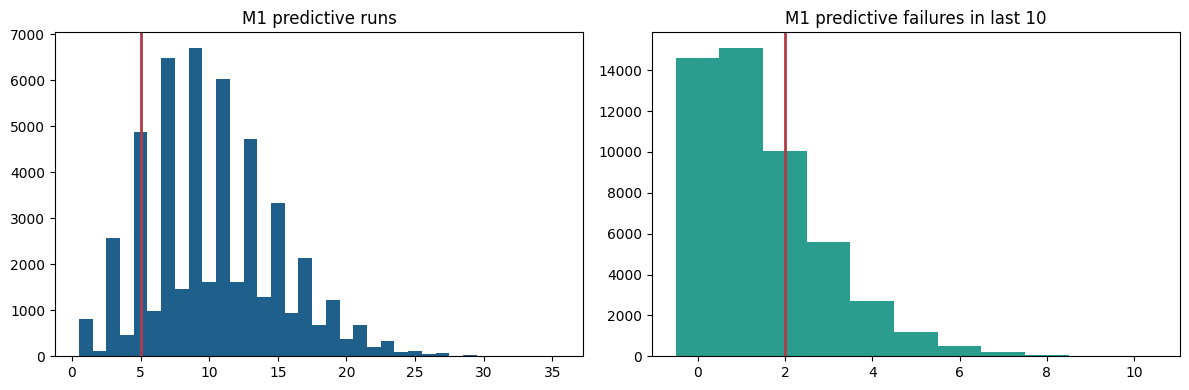

In [19]:
def longest_failure_run(sequence):
    longest = current = 0
    for value in sequence:
        current = current + 1 if value == 0 else 0; longest = max(longest, current)
    return longest

replicated = np.empty((SIMULATIONS, n), dtype=int)
for i, k in enumerate(sampled_k):
    p1 = rng.beta(1 + y[:k].sum(), 1 + k - y[:k].sum())
    p2 = rng.beta(1 + y[k:].sum(), 1 + len(y[k:]) - y[k:].sum())
    replicated[i, :k] = rng.binomial(1, p1, k); replicated[i, k:] = rng.binomial(1, p2, n-k)

observed_failures = int((y == 0).sum()); observed_f2f = int(((y[:-1] == 0) & (y[1:] == 0)).sum()); observed_runs = 1 + int(np.sum(y[1:] != y[:-1]))
observed_recent10 = int((y[-10:] == 0).sum()); observed_final2 = int((y[-2:] == 0).all())
rep_failures = (replicated == 0).sum(axis=1); rep_f2f = ((replicated[:, :-1] == 0) & (replicated[:, 1:] == 0)).sum(axis=1)
rep_runs = 1 + (replicated[:, 1:] != replicated[:, :-1]).sum(axis=1); rep_recent10 = (replicated[:, -10:] == 0).sum(axis=1)
rep_final2 = ((replicated[:, -2:] == 0).all(axis=1)); rep_longest = np.array([longest_failure_run(row) for row in replicated])

ppc_table = pd.DataFrame([
    {'statistic': 'Total failures', 'observed': observed_failures, 'predictive_mean': rep_failures.mean(), 'tail_probability': (rep_failures >= observed_failures).mean()},
    {'statistic': 'Failure-to-failure transitions', 'observed': observed_f2f, 'predictive_mean': rep_f2f.mean(), 'tail_probability': (rep_f2f >= observed_f2f).mean()},
    {'statistic': 'Runs, lower-tail', 'observed': observed_runs, 'predictive_mean': rep_runs.mean(), 'tail_probability': (rep_runs <= observed_runs).mean()},
    {'statistic': 'Failures in last 10', 'observed': observed_recent10, 'predictive_mean': rep_recent10.mean(), 'tail_probability': (rep_recent10 >= observed_recent10).mean()},
    {'statistic': 'Final two launches fail', 'observed': observed_final2, 'predictive_mean': rep_final2.mean(), 'tail_probability': rep_final2.mean()},
    {'statistic': 'Longest failure run', 'observed': int(longest_failure_run(y)), 'predictive_mean': rep_longest.mean(), 'tail_probability': (rep_longest >= longest_failure_run(y)).mean()},
])
display(ppc_table)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rep_runs, bins=np.arange(rep_runs.min(), rep_runs.max()+2)-0.5, color='#1f5f8b'); axes[0].axvline(observed_runs, color='#b23a48', linewidth=2); axes[0].set_title('M1 predictive runs')
axes[1].hist(rep_recent10, bins=np.arange(rep_recent10.min(), rep_recent10.max()+2)-0.5, color='#2a9d8f'); axes[1].axvline(observed_recent10, color='#b23a48', linewidth=2); axes[1].set_title('M1 predictive failures in last 10')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_04_change_point_ppc.png', dpi=180); plt.show()

## 6. Small out-of-sample forecasting check

A model that explains the past should also make sensible predictions for held-out launches. We use three historical training cutoffs and forecast the next ten launches. Scores are log predictive density (higher is better) and Brier score (lower is better). This is a small diagnostic because the dataset is small.

,cutoff,test_range,model,log_score,brier_score
0,20,21-30,M0 constant,-0.095310,0.008264
1,20,21-30,M1 change point,-0.087011,0.006944
2,25,26-35,M0 constant,-0.076961,0.005487
3,25,26-35,M1 change point,-0.071286,0.004734
4,30,31-40,M0 constant,-0.064539,0.003906
5,30,31-40,M1 change point,-0.060295,0.003424
6,35,36-45,M0 constant,-0.341790,0.092111
7,35,36-45,M1 change point,-0.344835,0.092414
8,40,41-50,M0 constant,-0.348363,0.092744
9,40,41-50,M1 change point,-0.351571,0.093027


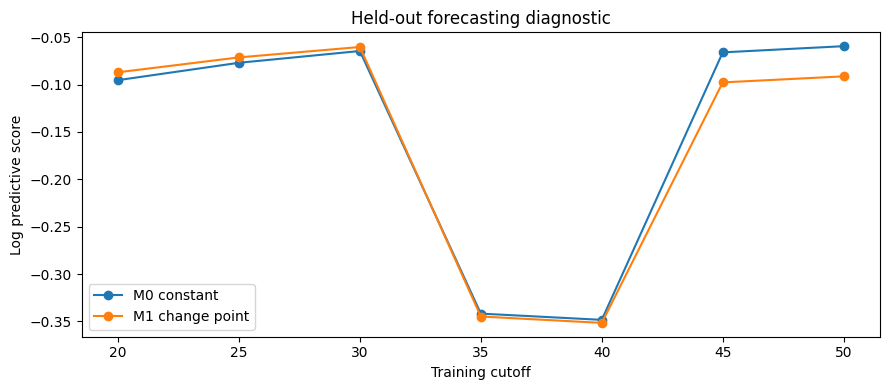

In [20]:
def score_predictions(actual, probabilities):
    probabilities = np.clip(probabilities, 1e-9, 1-1e-9)
    log_score = np.mean(actual * np.log(probabilities) + (1-actual) * np.log(1-probabilities))
    brier = np.mean((probabilities - actual)**2)
    return log_score, brier

forecast_rows = []
for cutoff in (20, 25, 30, 35, 40, 45, 50):
    train = y[:cutoff]; test = y[cutoff:cutoff+10]
    const_fit = fit_constant(train); const_prob = np.repeat(const_fit['posterior'].mean(), len(test))
    cp_fit = fit_change_point(train); cp_prob = np.zeros(len(test))
    for k, weight in zip(cp_fit['candidates'], cp_fit['posterior_k']):
        second = train[k:]; cp_prob += weight * (1 + second.sum()) / (2 + len(second))
    const_log, const_brier = score_predictions(test, const_prob); cp_log, cp_brier = score_predictions(test, cp_prob)
    forecast_rows.extend([
        {'cutoff': cutoff, 'test_range': f'{cutoff+1}-{cutoff+10}', 'model': 'M0 constant', 'log_score': const_log, 'brier_score': const_brier},
        {'cutoff': cutoff, 'test_range': f'{cutoff+1}-{cutoff+10}', 'model': 'M1 change point', 'log_score': cp_log, 'brier_score': cp_brier},
    ])
forecast_table = pd.DataFrame(forecast_rows)
display(forecast_table)
fig, ax = plt.subplots(figsize=(9, 4))
for model, group in forecast_table.groupby('model'): ax.plot(group.cutoff, group.log_score, marker='o', label=model)
ax.set_xlabel('Training cutoff'); ax.set_ylabel('Log predictive score'); ax.set_title('Held-out forecasting diagnostic'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_05_out_of_sample_scores.png', dpi=180); plt.show()
forecast_table.to_csv(RESULTS_DIR / 'out_of_sample_scores.csv', index=False)

## 7. Practical interpretation and limitations

The main quantities are probabilities, not declarations. `P(p_before > p_after)` asks whether the posterior supports lower reliability after a candidate split. `P(p_before-p_after > 0.05)` asks whether the decrease is practically meaningful. The recent model has only two launches after C61, so its uncertainty must remain large.

The one-change-point model is useful only if it improves evidence or prediction enough to justify its extra flexibility. A posterior mass near the end of the candidate range should not be treated as proof that C61 caused a permanent change. Engineering causes and configuration effects are outside this baseline.

In [21]:
degradation_table = pd.DataFrame([
    {'quantity': 'Posterior mode k', 'value': k_mode},
    {'quantity': 'Posterior mean k', 'value': k_mean},
    {'quantity': 'Posterior 95% k lower', 'value': k_lower},
    {'quantity': 'Posterior 95% k upper', 'value': k_upper},
    {'quantity': 'P(p_before > p_after)', 'value': np.mean(delta > 0)},
    {'quantity': 'P(degradation > 0.05)', 'value': np.mean(delta > 0.05)},
    {'quantity': 'P(degradation > 0.10)', 'value': np.mean(delta > 0.10)},
    {'quantity': 'P(k is in recent pre-specified period)', 'value': 0.0},
])
# The unknown-k model ends at k=54 by design; the recent k=62 model is reported separately.
degradation_table.loc[degradation_table.quantity == 'P(k is in recent pre-specified period)', 'value'] = np.nan
display(degradation_table)

# Change-point prior sensitivity: different defensible priors over k.
def fit_change_point_with_prior(values, candidates, prior_weights):
    log_by_k = np.array([segment_log_evidence(values[:k]) + segment_log_evidence(values[k:]) for k in candidates])
    log_prior = np.log(prior_weights / prior_weights.sum())
    log_evidence = logsumexp(log_by_k + log_prior)
    return {'candidates': candidates, 'log_by_k': log_by_k, 'log_evidence': log_evidence, 'posterior_k': np.exp(log_by_k + log_prior - log_evidence)}

prior_specs = {
    'Uniform k=10..54': (np.arange(10, 55), None),
    'Uniform k=10..50': (np.arange(10, 51), None),
    'Uniform k=15..54': (np.arange(15, 55), None),
    'Less weight near recent boundary': (np.arange(10, 55), np.exp(-0.04 * (np.arange(10, 55) - 10))),
}
prior_sensitivity_rows = []
for label, (candidate_values, weights) in prior_specs.items():
    if weights is None: weights = np.ones(len(candidate_values))
    fit = fit_change_point_with_prior(y, candidate_values, weights)
    _, before_draws, after_draws = sample_change_point_posterior(y, fit, draws=20000, seed=20261001)
    d = before_draws - after_draws
    mode = int(candidate_values[np.argmax(fit['posterior_k'])])
    prior_sensitivity_rows.append({'prior': label, 'posterior_mode_k': mode, 'posterior_mean_k': np.sum(candidate_values * fit['posterior_k']), 'posterior_mass_k_ge_50': fit['posterior_k'][candidate_values >= 50].sum(), 'P(before > after)': np.mean(d > 0), 'P(degradation > 0.05)': np.mean(d > 0.05), 'P(degradation > 0.10)': np.mean(d > 0.10)})
prior_sensitivity = pd.DataFrame(prior_sensitivity_rows)
display(prior_sensitivity)
prior_sensitivity.to_csv(RESULTS_DIR / 'change_point_prior_sensitivity.csv', index=False)

# The unknown-k result is exploratory. k=62 is not part of M1 because M1 requires 10 launches per segment.
boundary_mass = float(k_table.loc[k_table.k >= 50, 'posterior_probability'].sum())
print(f'Posterior mass on k >= 50: {boundary_mass:.4f}')

model_comparison.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
k_table.to_csv(RESULTS_DIR / 'change_point_posterior.csv', index=False)
regime_summary.to_csv(RESULTS_DIR / 'regime_difference_summary.csv', index=False)
recent_summary.to_csv(RESULTS_DIR / 'recent_period_summary.csv', index=False)
ppc_table.to_csv(RESULTS_DIR / 'change_point_ppc.csv', index=False)
degradation_table.to_csv(RESULTS_DIR / 'degradation_summary.csv', index=False)

report = [
    '# Step 4 Bayesian change-point report', '',
    'The constant model M0 is compared with an analytically integrated one-change-point model M1, a pre-specified recent k=62 model M2, and a simple Bayesian logistic trend M3.', '',
    f'M1 posterior mode of k: {k_mode}; posterior mean: {k_mean:.2f}; 95% interval: [{k_lower}, {k_upper}].',
    f'P(p_before > p_after): {np.mean(delta > 0):.4f}.',
    f'P(degradation > 0.05): {np.mean(delta > 0.05):.4f}.',
    f'P(degradation > 0.10): {np.mean(delta > 0.10):.4f}.',
    f'Recent k=62 P(p_old > p_recent): {np.mean(recent_delta > 0):.4f}; this analysis is exploratory because the window is motivated by C61/C62.',
    f'M1 posterior mass on k >= 50: {boundary_mass:.4f}; this boundary concentration does not identify a unique change point.',
    'Change-point prior sensitivity is saved in change_point_prior_sensitivity.csv.',
    f'Model comparison Bayes factors are in model_comparison.csv; M1 uses a uniform prior over k=10,...,54.', '',
    'Interpretation: a change-point posterior is evidence about possible temporal variation, not proof that C61 or C62 caused a permanent reliability change.', '',
    'Limitations:',
    '- Only four failures are observed.',
    '- The recent regime contains only two launches.',
    '- Configuration and engineering covariates are not modeled.',
    '- The smooth trend uses a numerical grid and is a secondary sensitivity model.',
    '- Out-of-sample scores use small ten-launch test blocks.',
]
(RESULTS_DIR / 'step4_report.md').write_text('\n'.join(report) + '\n', encoding='utf-8')
print('STEP 4 COMPLETE')
print(f'M1 change-point mode: k={k_mode}')
print(f'P(degradation > 0.05): {np.mean(delta > 0.05):.4f}')
print('Model comparison, predictive checks, and out-of-sample diagnostics: PASS')

,quantity,value
0,Posterior mode k,54.00000
1,Posterior mean k,37.41550
2,Posterior 95% k lower,11.00000
3,Posterior 95% k upper,54.00000
4,P(p_before > p_after),0.78244
5,P(degradation > 0.05),0.57952
6,P(degradation > 0.10),0.37460
7,P(k is in recent pre-specified period),NaN


,prior,posterior_mode_k,posterior_mean_k,posterior_mass_k_ge_50,P(before > after),P(degradation > 0.05),P(degradation > 0.10)
0,Uniform k=10..54,54,37.415500,0.269578,0.78415,0.58175,0.3745
1,Uniform k=10..50,40,32.736187,0.046797,0.73230,0.50085,0.2754
2,Uniform k=15..54,54,39.807861,0.294786,0.83180,0.62045,0.4064
3,Less weight near recent boundary,10,29.499027,0.126869,0.65265,0.42950,0.2460


Posterior mass on k >= 50: 0.2696
STEP 4 COMPLETE
M1 change-point mode: k=54
P(degradation > 0.05): 0.5795
Model comparison, predictive checks, and out-of-sample diagnostics: PASS


,time_definition,posterior_mean_slope,P(slope < 0)
0,Launch index,-0.535863,0.774733
1,Calendar time,-0.130869,0.549239


,recent_launches,change_point_k,P(old > recent),P(old - recent > 0.05),P(old - recent > 0.10),old_posterior_mean,recent_posterior_mean
0,2,62,0.999800,0.999067,0.996700,0.953171,0.249701
1,3,61,0.999333,0.995933,0.987600,0.952349,0.399459
2,4,60,0.998133,0.990533,0.973067,0.951461,0.500992
3,5,59,0.995233,0.981100,0.948600,0.950660,0.571154
4,6,58,0.993100,0.968267,0.920967,0.949839,0.623693


,model,mean_log_score,mean_brier_score,windows
0,M0 constant,-0.150335,0.029988,7
1,M1 change point,-0.157710,0.030974,7
2,M3 smooth trend,-0.150710,0.029997,7


,metric,observed_mean_difference,bootstrap_lower_95,bootstrap_upper_95
0,log_difference_M1_minus_M0,-0.007375,-0.019542,0.003501
1,brier_difference_M1_minus_M0,0.000986,-0.000542,0.002701


,model,probability_bin,mean_predicted,observed_success_rate,observations
0,M0 constant,"(-0.001, 0.9]",NaN,NaN,0
1,M0 constant,"(0.9, 0.925]",0.909091,1.000000,10
2,M0 constant,"(0.925, 0.95]",0.937570,0.980000,50
3,M0 constant,"(0.95, 0.975]",0.952381,0.900000,10
4,M0 constant,"(0.975, 1.0]",NaN,NaN,0
5,M1 change point,"(-0.001, 0.9]",NaN,NaN,0
6,M1 change point,"(0.9, 0.925]",0.912120,1.000000,30
7,M1 change point,"(0.925, 0.95]",0.940603,0.966667,30
8,M1 change point,"(0.95, 0.975]",0.955017,0.900000,10
9,M1 change point,"(0.975, 1.0]",NaN,NaN,0


,model,time_definition,temporal_coefficient,predicted_probability_early,predicted_probability_late,interpretation
0,Configuration only,none,NaN,0.939771,0.939771,Descriptive sensitivity; not the primary model
1,Configuration + launch-index time,launch index,-0.560446,0.965992,0.902532,Descriptive sensitivity; not the primary model
2,Configuration + calendar time,calendar time,-0.182180,0.951795,0.932044,Descriptive sensitivity; not the primary model


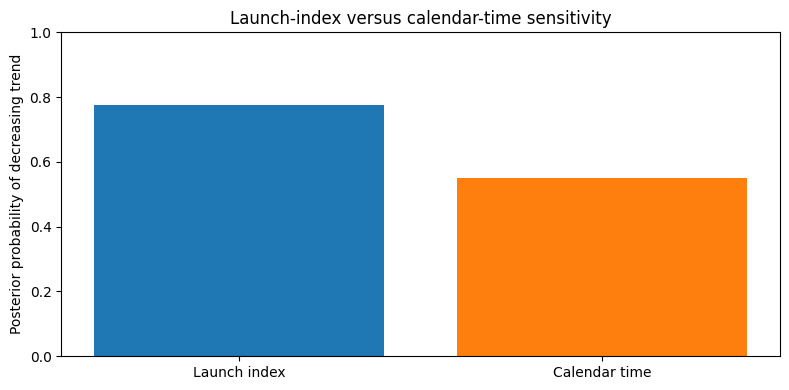

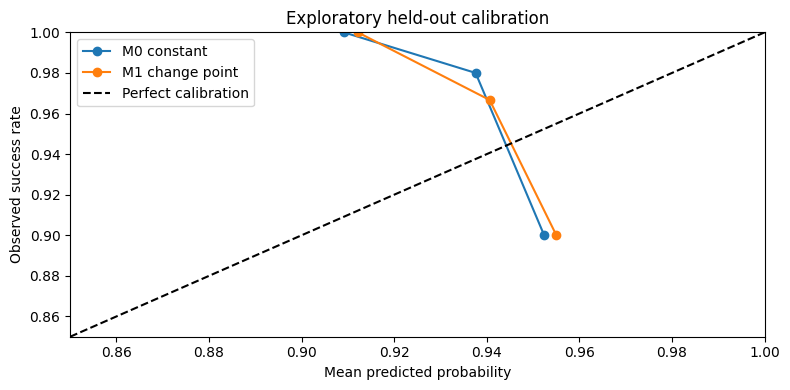

Supplemental Step 4 sensitivity analyses: PASS


In [22]:
# Supplemental sensitivity analyses requested for the research-quality update.
# These analyses are secondary because only four failures are observed.
data['calendar_time_0_to_1'] = (pd.to_datetime(data['calendar_date']) - pd.to_datetime(data['calendar_date']).min()).dt.days / (pd.to_datetime(data['calendar_date']).max() - pd.to_datetime(data['calendar_date']).min()).days
index_time = (np.arange(n) - (n - 1) / 2) / (n / 2)
calendar_time = 2 * data['calendar_time_0_to_1'].to_numpy() - 1

def fit_grid_trend(time_values, outcomes):
    intercept_values = np.linspace(-4, 4, 121)
    slope_values = np.linspace(-4, 4, 121)
    log_weights = np.empty((len(intercept_values), len(slope_values)))
    for i, intercept in enumerate(intercept_values):
        eta = intercept + slope_values[:, None] * time_values[None, :]
        log_likelihood = (outcomes[None, :] * (-np.logaddexp(0, -eta)) + (1 - outcomes[None, :]) * (-np.logaddexp(0, eta))).sum(axis=1)
        log_weights[i, :] = log_likelihood + norm.logpdf(intercept, 0, 2.5) + norm.logpdf(slope_values, 0, 1)
    weights = np.exp(log_weights - logsumexp(log_weights))
    return {'posterior_mean_slope': float(np.sum(weights * slope_values[None, :])), 'P(slope < 0)': float(np.sum(weights[:, slope_values < 0])), 'weights': weights, 'intercepts': intercept_values, 'slopes': slope_values}

index_trend_sensitivity = fit_grid_trend(index_time, y)
calendar_trend_sensitivity = fit_grid_trend(calendar_time, y)
time_sensitivity = pd.DataFrame([
    {'time_definition': 'Launch index', 'posterior_mean_slope': index_trend_sensitivity['posterior_mean_slope'], 'P(slope < 0)': index_trend_sensitivity['P(slope < 0)']},
    {'time_definition': 'Calendar time', 'posterior_mean_slope': calendar_trend_sensitivity['posterior_mean_slope'], 'P(slope < 0)': calendar_trend_sensitivity['P(slope < 0)']},
])
display(time_sensitivity)
time_sensitivity.to_csv(RESULTS_DIR / 'calendar_vs_index_time_sensitivity.csv', index=False)

# Nearby recent windows: last 2, 3, 4, 5, and 6 launches.
recent_window_rows = []
for recent_size in range(2, 7):
    k = n - recent_size
    old = y[:k]; recent = y[k:]
    local_rng = np.random.default_rng(20261001 + recent_size)
    old_draws = local_rng.beta(1 + old.sum(), 1 + len(old) - old.sum(), 30000)
    recent_draws = local_rng.beta(1 + recent.sum(), 1 + len(recent) - recent.sum(), 30000)
    difference = old_draws - recent_draws
    recent_window_rows.append({'recent_launches': recent_size, 'change_point_k': k, 'P(old > recent)': np.mean(difference > 0), 'P(old - recent > 0.05)': np.mean(difference > 0.05), 'P(old - recent > 0.10)': np.mean(difference > 0.10), 'old_posterior_mean': old_draws.mean(), 'recent_posterior_mean': recent_draws.mean()})
recent_window_sensitivity = pd.DataFrame(recent_window_rows)
display(recent_window_sensitivity)
recent_window_sensitivity.to_csv(RESULTS_DIR / 'recent_window_sensitivity.csv', index=False)

# Add the smooth trend model to the same seven rolling-origin test windows.
trend_forecast_rows = []
for cutoff in (20, 25, 30, 35, 40, 45, 50):
    train = y[:cutoff]; test = y[cutoff:cutoff + 10]
    trend_fit = fit_grid_trend(index_time[:cutoff], train)
    trend_probabilities = np.zeros(len(test))
    for i, intercept in enumerate(trend_fit['intercepts']):
        trend_probabilities += np.sum(trend_fit['weights'][i, :, None] * expit(intercept + trend_fit['slopes'][:, None] * index_time[cutoff:cutoff + 10][None, :]), axis=0)
    trend_log, trend_brier = score_predictions(test, trend_probabilities)
    trend_forecast_rows.append({'cutoff': cutoff, 'test_range': f'{cutoff + 1}-{cutoff + 10}', 'model': 'M3 smooth trend', 'log_score': trend_log, 'brier_score': trend_brier})
forecast_table_with_m3 = pd.concat([forecast_table, pd.DataFrame(trend_forecast_rows)], ignore_index=True)
forecast_table_with_m3.to_csv(RESULTS_DIR / 'out_of_sample_scores_with_m3.csv', index=False)
score_summary = forecast_table_with_m3.groupby('model').agg(mean_log_score=('log_score', 'mean'), mean_brier_score=('brier_score', 'mean'), windows=('cutoff', 'count')).reset_index()
paired_scores = forecast_table.pivot(index='cutoff', columns='model', values=['log_score', 'brier_score'])
paired_scores['log_difference_M1_minus_M0'] = paired_scores[('log_score', 'M1 change point')] - paired_scores[('log_score', 'M0 constant')]
paired_scores['brier_difference_M1_minus_M0'] = paired_scores[('brier_score', 'M1 change point')] - paired_scores[('brier_score', 'M0 constant')]
bootstrap_rng = np.random.default_rng(20261001)
bootstrap_rows = []
for column in ('log_difference_M1_minus_M0', 'brier_difference_M1_minus_M0'):
    observed_difference = float(paired_scores[column].mean())
    values = paired_scores[column].to_numpy()
    bootstrap_means = np.array([bootstrap_rng.choice(values, size=len(values), replace=True).mean() for _ in range(10000)])
    bootstrap_rows.append({'metric': column, 'observed_mean_difference': observed_difference, 'bootstrap_lower_95': np.quantile(bootstrap_means, 0.025), 'bootstrap_upper_95': np.quantile(bootstrap_means, 0.975)})
bootstrap_score_differences = pd.DataFrame(bootstrap_rows)
display(score_summary); display(bootstrap_score_differences)
score_summary.to_csv(RESULTS_DIR / 'aggregate_forecasting_scores.csv', index=False)
bootstrap_score_differences.to_csv(RESULTS_DIR / 'bootstrap_forecasting_score_differences.csv', index=False)

# Exploratory calibration diagnostic using every held-out prediction.
calibration_rows = []
for cutoff in (20, 25, 30, 35, 40, 45, 50):
    train = y[:cutoff]; test = y[cutoff:cutoff + 10]
    const_probability = np.repeat(fit_constant(train)['posterior'].mean(), len(test))
    cp_fit = fit_change_point(train); cp_probability = np.zeros(len(test))
    for k, weight in zip(cp_fit['candidates'], cp_fit['posterior_k']): cp_probability += weight * (1 + train[k:].sum()) / (2 + len(train[k:]))
    for row_number, observed_value in enumerate(test):
        calibration_rows.extend([{'model': 'M0 constant', 'cutoff': cutoff, 'predicted_probability': const_probability[row_number], 'observed_success': observed_value}, {'model': 'M1 change point', 'cutoff': cutoff, 'predicted_probability': cp_probability[row_number], 'observed_success': observed_value}])
calibration_predictions = pd.DataFrame(calibration_rows)
calibration_predictions['probability_bin'] = pd.cut(calibration_predictions['predicted_probability'], bins=[0, 0.90, 0.925, 0.95, 0.975, 1.0], include_lowest=True)
calibration_summary = calibration_predictions.groupby(['model', 'probability_bin'], observed=False).agg(mean_predicted=('predicted_probability', 'mean'), observed_success_rate=('observed_success', 'mean'), observations=('observed_success', 'size')).reset_index()
display(calibration_summary)
calibration_predictions.to_csv(RESULTS_DIR / 'calibration_predictions.csv', index=False)
calibration_summary.to_csv(RESULTS_DIR / 'calibration_summary.csv', index=False)

# Configuration-adjusted sensitivity: penalized logistic fits, descriptive only.
configuration_matrix = pd.get_dummies(data['variant_standard'].fillna('UNKNOWN'), drop_first=True, dtype=float).to_numpy()
def fit_penalized_logistic(design_matrix, outcomes, penalty=1.0):
    def objective(coefficients):
        linear_predictor = design_matrix @ coefficients
        log_likelihood = np.sum(outcomes * (-np.logaddexp(0, -linear_predictor)) + (1 - outcomes) * (-np.logaddexp(0, linear_predictor)))
        return -log_likelihood + penalty * np.sum(coefficients[1:] ** 2) / 2
    return minimize(objective, np.zeros(design_matrix.shape[1]), method='BFGS').x
config_only_design = np.column_stack([np.ones(n), configuration_matrix])
config_index_design = np.column_stack([np.ones(n), configuration_matrix, index_time])
config_calendar_design = np.column_stack([np.ones(n), configuration_matrix, calendar_time])
configuration_sensitivity_rows = []
for label, design, time_name in [('Configuration only', config_only_design, 'none'), ('Configuration + launch-index time', config_index_design, 'launch index'), ('Configuration + calendar time', config_calendar_design, 'calendar time')]:
    coefficients = fit_penalized_logistic(design, y)
    temporal_coefficient = float(coefficients[-1]) if time_name != 'none' else np.nan
    early_design = design.mean(axis=0); late_design = early_design.copy()
    if time_name != 'none': early_design[-1] = -1; late_design[-1] = 1
    configuration_sensitivity_rows.append({'model': label, 'time_definition': time_name, 'temporal_coefficient': temporal_coefficient, 'predicted_probability_early': expit(early_design @ coefficients), 'predicted_probability_late': expit(late_design @ coefficients), 'interpretation': 'Descriptive sensitivity; not the primary model'})
configuration_sensitivity = pd.DataFrame(configuration_sensitivity_rows)
display(configuration_sensitivity)
configuration_sensitivity.to_csv(RESULTS_DIR / 'configuration_adjusted_sensitivity.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(time_sensitivity['time_definition'], time_sensitivity['P(slope < 0)'], color=['tab:blue', 'tab:orange'])
ax.set_ylim(0, 1); ax.set_ylabel('Posterior probability of decreasing trend'); ax.set_title('Launch-index versus calendar-time sensitivity')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_06_calendar_vs_index_time.png', dpi=200); plt.show()
fig, ax = plt.subplots(figsize=(8, 4))
for model, group in calibration_summary.groupby('model'):
    group = group.dropna(subset=['mean_predicted', 'observed_success_rate'])
    ax.plot(group['mean_predicted'], group['observed_success_rate'], marker='o', label=model)
ax.plot([0.85, 1], [0.85, 1], '--', color='black', label='Perfect calibration')
ax.set(xlim=(0.85, 1), ylim=(0.85, 1), xlabel='Mean predicted probability', ylabel='Observed success rate', title='Exploratory held-out calibration')
ax.legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step4_07_calibration.png', dpi=200); plt.show()

supplemental_report = [
    '', '## Supplemental sensitivity analyses',
    'The sequential update, calendar-time comparison, configuration-adjusted fits, recent-window grid, aggregate forecasting scores, bootstrap score intervals, and calibration diagnostic are secondary analyses.',
    f'Launch-index trend P(slope < 0): {index_trend_sensitivity["P(slope < 0)"]:.4f}.',
    f'Calendar-time trend P(slope < 0): {calendar_trend_sensitivity["P(slope < 0)"]:.4f}.',
    'Configuration-adjusted fits are penalized logistic sensitivities and are not used as the primary inferential model.',
    'Recent-window results cover the last 2 through 6 launches; the two-launch result must not be treated as confirmatory.',
    'Forecasting score intervals bootstrap the seven historical windows, so they describe window uncertainty rather than pretending to have seven independent large samples.',
]
(RESULTS_DIR / 'step4_report.md').write_text((RESULTS_DIR / 'step4_report.md').read_text(encoding='utf-8') + '\n'.join(supplemental_report) + '\n', encoding='utf-8')
print('Supplemental Step 4 sensitivity analyses: PASS')
